<a href="https://colab.research.google.com/github/hoangchaugiahan/FUZZYLOGIC/blob/main/Flowers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Dropout

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
datagen = ImageDataGenerator(rescale=1.0/255)
generator = datagen.flow_from_directory(
    '//content/drive/MyDrive/Flowers',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)
test_generator = datagen.flow_from_directory(
    '//content/drive/MyDrive/Flowers',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)

class_labels = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
X_batch, y_batch = next(generator)
X_batch_flat = X_batch.reshape(X_batch.shape[0], -1)
print("Input shape for ANN:", X_batch_flat.shape)
print("Label shape (one-hot):", y_batch.shape)

Found 484 images belonging to 5 classes.
Found 484 images belonging to 5 classes.
Input shape for ANN: (32, 3072)
Label shape (one-hot): (32, 5)


In [21]:
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/Flowers',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)
x_train, y_train = next(generator)
x_test, y_test = next(test_generator)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
model = Sequential([
    Dense(256, activation='relu', input_shape=(32*32*3,)),
    Dense(128, activation='relu'),
    Dense(generator.num_classes, activation='softmax')

])

Found 484 images belonging to 5 classes.
(32, 3072) (32, 5)
(484, 3072) (484, 5)


In [22]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=700, batch_size=100, validation_data=(x_test, y_test))

Epoch 1/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step - accuracy: 0.0938 - loss: 1.6949 - val_accuracy: 0.4277 - val_loss: 2.3489
Epoch 2/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.3750 - loss: 2.1961 - val_accuracy: 0.2045 - val_loss: 1.6895
Epoch 3/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3750 - loss: 1.3885 - val_accuracy: 0.2355 - val_loss: 1.6325
Epoch 4/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.4062 - loss: 1.3545 - val_accuracy: 0.3802 - val_loss: 1.4407
Epoch 5/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7812 - loss: 1.1051 - val_accuracy: 0.4298 - val_loss: 1.4259
Epoch 6/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6562 - loss: 0.9696 - val_accuracy: 0.4463 - val_loss: 1.4690
Epoch 7/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6250 - loss: 0.8694 - val_accuracy: 0.4669 - val_loss: 1.4613
Epoch 8/700
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8125 - loss: 0.7674 - val_accuracy: 0.4773 - val_

In [23]:
t_loss,test_acc=model.evaluate(x_test,y_test)
print('test_acc:%.2f'%(test_acc*100))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4104 - loss: 3.8581 
test_acc:53.51


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Dự đoán: tulip


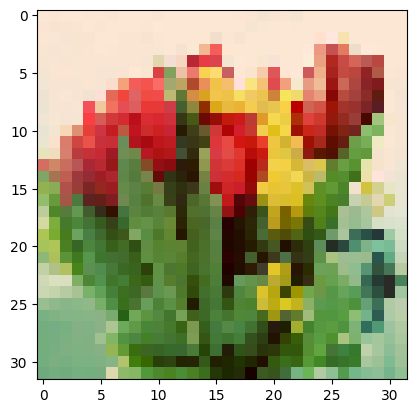

In [32]:

img=load_img('/content/drive/MyDrive/Flowers/tulip/16751015081_af2ef77c9a_n.jpg', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') / 255.0
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Dự đoán: sunflower


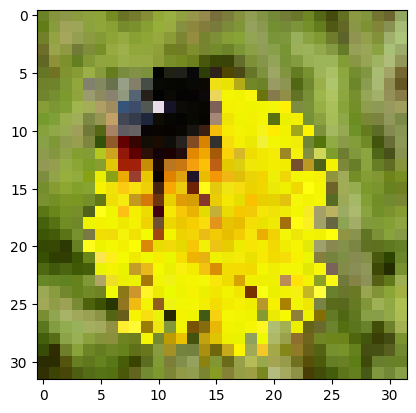

In [24]:

img=load_img('/content/drive/MyDrive/Flowers/dandelion/17457028309_95514c8d02_n.jpg', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') / 255.0
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Dự đoán: rose


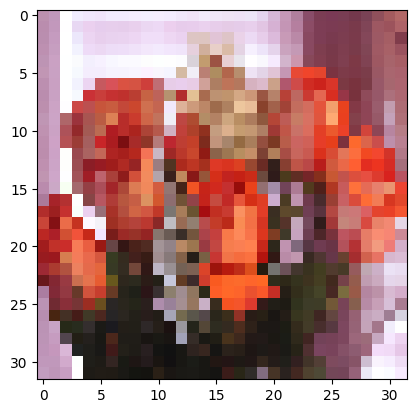

In [37]:

img=load_img('/content/drive/MyDrive/Flowers/rose/15424480096_45bb574b33.jpg', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') / 255.0
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Dự đoán: daisy


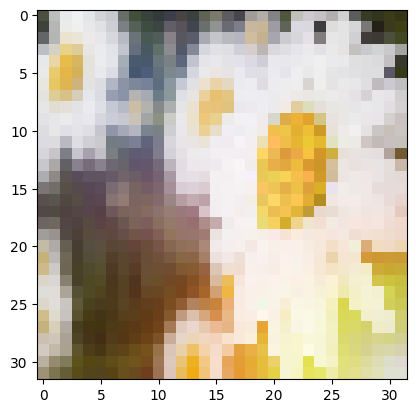

In [16]:

img=load_img('/content/drive/MyDrive/Flowers/daisy/19177263840_6a316ea639.jpg', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') / 255.0
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Dự đoán: dandelion


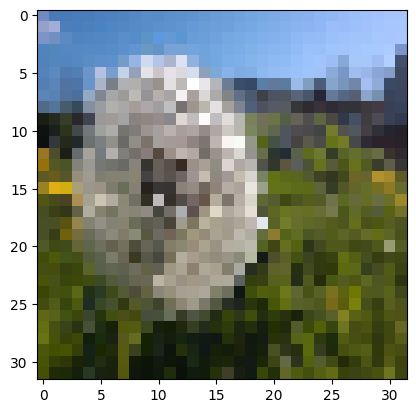

In [36]:
img=load_img('/content/drive/MyDrive/Flowers/dandelion/17280886635_e384d91300_n.jpg', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') / 255.0
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])